In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [2]:
# Parámetros generales
image_height = 224
image_width = 224
batch_size = 32
epochs = 20
input_shape = (image_height, image_width, 3)
num_classes = None  # Se infiere del generador

data_dir = "Datos Finales"
metadata_file = "Metadatos_Finales.csv"

df = pd.read_csv(metadata_file, sep=";")
df = df.rename(columns={'Nombre del archivo': 'image_id'})
df['Planta_Estado_Español'] = df['Planta_Estado_Español'].astype(str)

categoria = 'Planta_Estado_Español'
image_id = 'image_id'

In [3]:
# Dividir en entrenamiento y validación
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Planta_Estado_Español'], random_state=42)
train_df.shape, test_df.shape

((42354, 12), (10589, 12))

In [4]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['Planta_Estado_Español'], random_state=42)
train_df.shape, val_df.shape

((33883, 12), (8471, 12))

In [5]:
# Total de clases
print("Clases:", df['Planta_Estado_Español'].nunique())
num_classes = df['Planta_Estado_Español'].nunique()
class_names = df['Planta_Estado_Español'].unique().tolist()
print(class_names)

Clases: 18
['Yuca_Enferma', 'Yuca_Saludable', 'Fresa_Saludable', 'Papa_Enferma', 'Maíz_Saludable', 'Tomate_Enferma', 'Manzana_Enferma', 'Maíz_Enferma', 'Tomate_Saludable', 'Manzana_Saludable', 'Fresa_Enferma', 'Papa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Fríjol_Enferma', 'Coliflor_Saludable', 'Fríjol_Saludable', 'Pepino Cohombro_Enferma']


In [6]:
# Crear el generador de imágenes -- 
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 27104 validated image filenames belonging to 18 classes.
Found 1694 validated image filenames belonging to 18 classes.


In [7]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,072,629 (15.54 MB)

 Trainable params: 23,058 (90.07 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

In [9]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 394s 462ms/step - accuracy: 0.3192 - loss: 2.1073 - val_accuracy: 0.5337 - val_loss: 1.9264 - learning_rate: 1.0000e-04
Epoch 2/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 414s 488ms/step - accuracy: 0.3443 - loss: 1.9312 - val_accuracy: 0.3456 - val_loss: 1.9126 - learning_rate: 1.0000e-04
Epoch 3/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 428s 505ms/step - accuracy: 0.3581 - loss: 1.9427 - val_accuracy: 0.3407 - val_loss: 1.9115 - learning_rate: 1.0000e-04
Epoch 4/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 430s 507ms/step - accuracy: 0.3662 - loss: 1.9259 - val_accuracy: 0.3425 - val_loss: 1.9080 - learning_rate: 1.0000e-04
Epoch 5/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 437s 516ms/step - accuracy: 0.3666 - loss: 1.9371 - val_accuracy: 0.3419 - val_loss: 1.9114 - learning_rate: 1.0000e-04
Epoch 6/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 436s 514ms/step - accuracy: 0.3709 - loss: 1.9318 - val_accuracy: 0.4243 - val_loss: 1.9041 - learning_rate: 1.0000e-04
Epoch 7/20
847/847 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 455ms/step - accuracy: 0.3295 - loss: 1.9669
Pérdida en la validación: 1.8986
Precisión en la validación: 0.3477


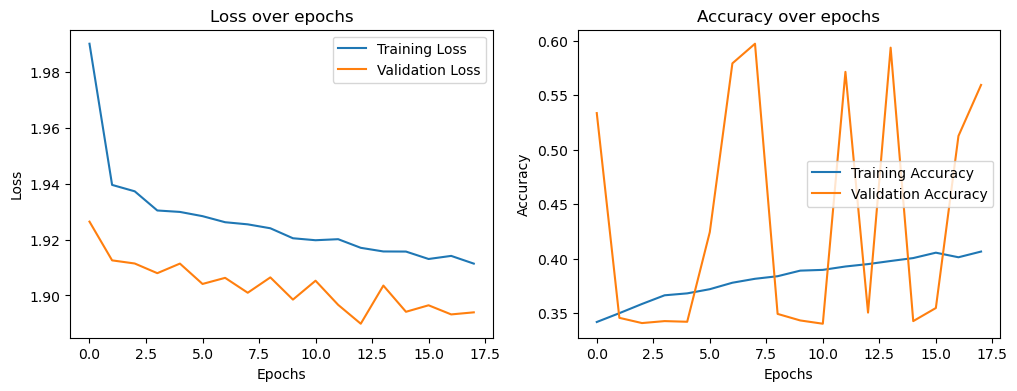

In [11]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [12]:
epochs = list(range(1, 20))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': 20,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      20        1.990156         1.926441           0.341721   
1      20        1.939595         1.912570           0.349838   
2      20        1.937304         1.911452           0.358287   
3      20        1.930435         1.907983           0.366256   
4      20        1.929922         1.911417           0.368027   
5      20        1.928405         1.904125           0.371864   
6      20        1.926232         1.906312           0.377804   
7      20        1.925472         1.900975           0.381420   
8      20        1.924067         1.906473           0.383781   
9      20        1.920490         1.898522           0.388909   
10     20        1.919784         1.905284           0.389610   
11     20        1.920154         1.896644           0.392710   
12     20        1.917067         1.889883           0.394923   
13     20        1.915760         1.903545           0.397764   
14     20        1.915724

In [13]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [14]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])


print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 1.9114060401916504
Pérdida final en Validation: 1.8939577341079712
Accuracy final en Train: 0.40643447637557983
Accuracy final en Validation: 0.559495210647583


In [18]:
test_df.Planta_Estado_Español = test_df.Planta_Estado_Español.astype('str')

test_generator =  datagen.flow_from_dataframe(test_df,
                         directory = data_dir,
                         x_col = image_id,
                         y_col = categoria,
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 10589 validated image filenames belonging to 18 classes.


In [19]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

331/331 ━━━━━━━━━━━━━━━━━━━━ 141s 422ms/step


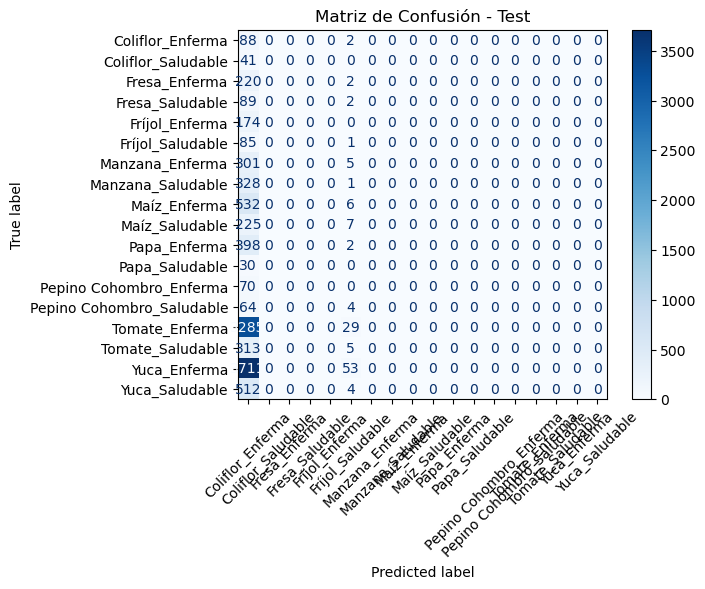

In [22]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0084


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

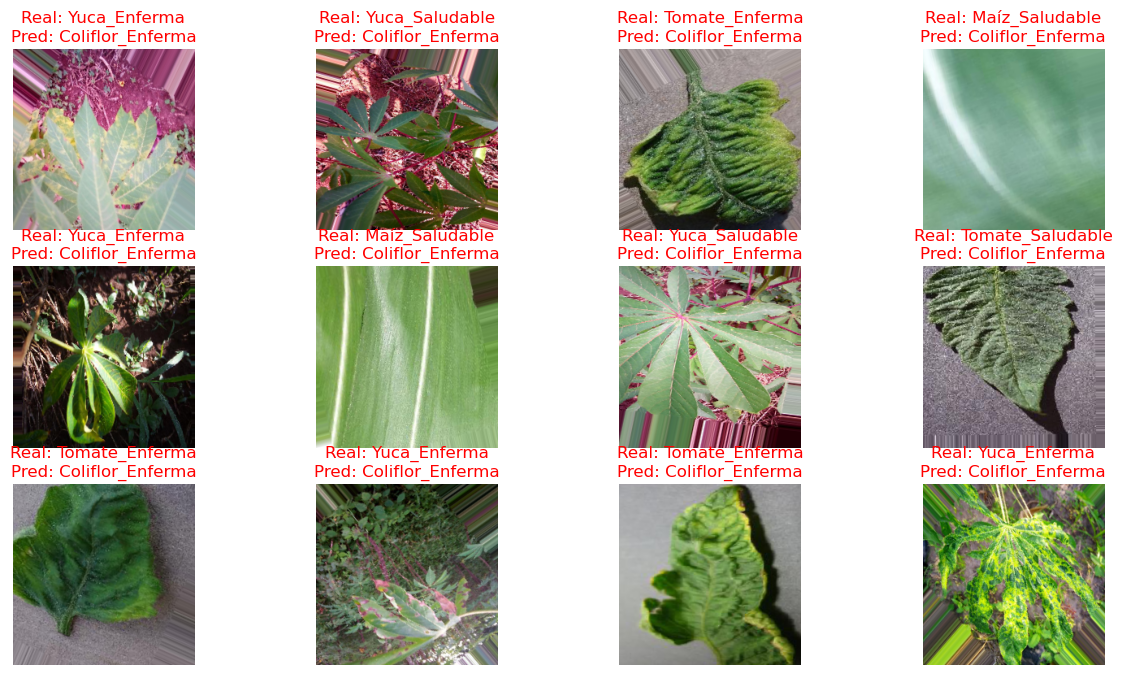

In [24]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

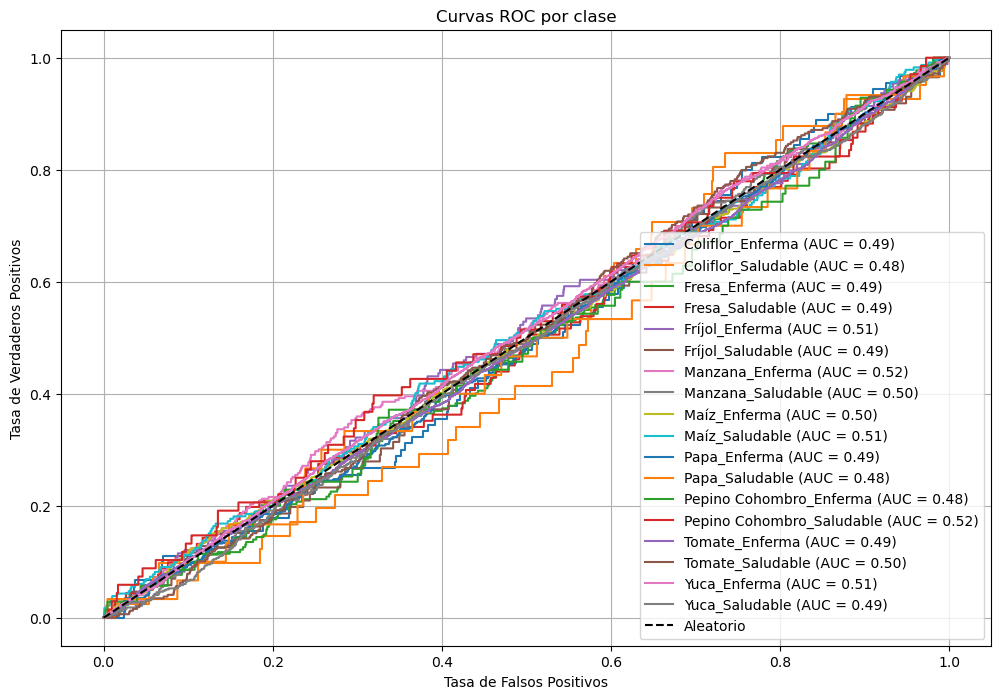

In [31]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical


# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.4958
AUC Micro promedio: 0.3939


In [35]:
from sklearn.metrics import f1_score
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.0084
F1 Score (macro): 0.0015
F1 Score (micro): 0.0084
F1 Score (weighted): 0.0002

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.01      0.98      0.02        90
       Coliflor_Saludable       0.00      0.00      0.00        41
            Fresa_Enferma       0.00      0.00      0.00       222
          Fresa_Saludable       0.00      0.00      0.00        91
           Fríjol_Enferma       0.00      0.00      0.00       174
         Fríjol_Saludable       0.01      0.01      0.01        86
          Manzana_Enferma       0.00      0.00      0.00       306
        Manzana_Saludable       0.00      0.00      0.00       329
             Maíz_Enferma       0.00      0.00      0.00       538
           Maíz_Saludable       0.00      0.00      0.00       232
             Papa_Enferma       0.00      0.00      0.00       400
           Papa_Saludable       0.00      0.00      0.00       

In [37]:
model.save('modelo_17_EfficientNet_Planta_Estado.h5')

In [39]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_17_EfficientNet_Planta_Estado.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Yuca_Enferma', 1: 'Yuca_Saludable', 2: 'Fresa_Saludable', 3: 'Papa_Enferma', 4: 'Maíz_Saludable', 5: 'Tomate_Enferma', 6: 'Manzana_Enferma', 7: 'Maíz_Enferma', 8: 'Tomate_Saludable', 9: 'Manzana_Saludable', 10: 'Fresa_Enferma', 11: 'Papa_Saludable', 12: 'Coliflor_Enferma', 13: 'Pepino Cohombro_Saludable', 14: 'Fríjol_Enferma', 15: 'Coliflor_Saludable', 16: 'Fríjol_Saludable', 17: 'Pepino Cohombro_Enferma'}
